Apply: 0.766m UP
Best correlation: 0.523


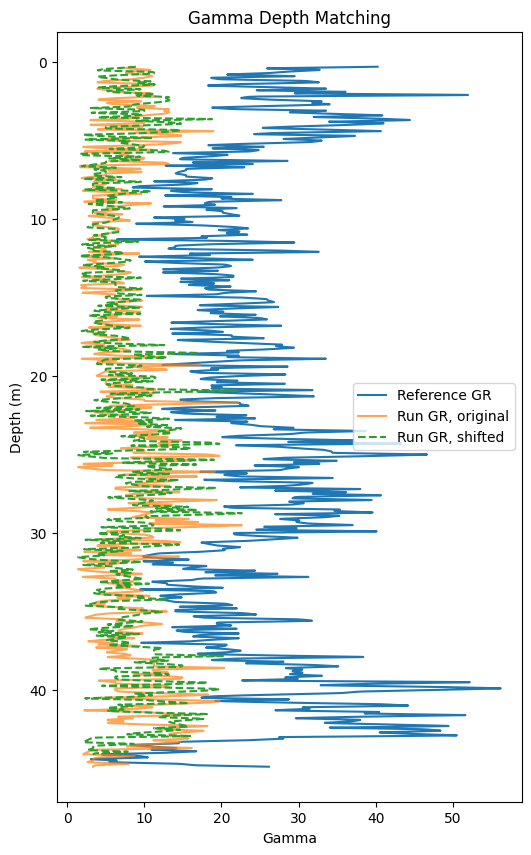

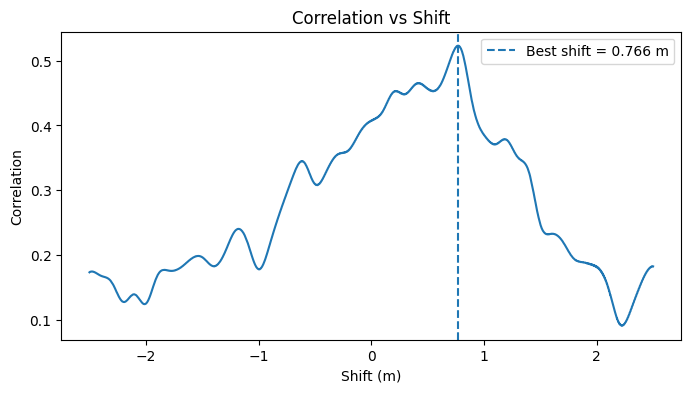

In [ ]:
import numpy as np
import lasio
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
import matplotlib
# matplotlib.use('Qt5Agg')  

#Enter Hole Name
hole_id = "BLD0051" 

#Enter the ref file name
reference_las_file = "BLD0051.las"

#Enter the LAS file name that needs to be depth shifted wrt to ref LAS file
las_file_for_shifting = "BLD0051.las"

#Enter how GAMMA curve is named in the reference and the other LAS files
ref_gr_curve = "GAMMA_M"
run_gr_curve = "GAMMA"

ref_las_file=f"{hole_id}/{reference_las_file}"
change_las_file=f"{hole_id}/{las_file_for_shifting}"


def read_las_curve(las_file, depth_curve="DEPT", gamma_curve="GR"):
    las = lasio.read(las_file)

    # Depth
    if depth_curve in las.curves:
        depth = np.array(las[depth_curve], dtype=float)
    else:
        depth = np.array(las.index, dtype=float)

    # Gamma
    if gamma_curve not in las.curves:
        raise ValueError(f"Curve '{gamma_curve}' not found in {las_file}")

    gamma = np.array(las[gamma_curve], dtype=float)

    # Null value from LAS header if available
    null_value = las.well.NULL.value if "NULL" in las.well else -999.25

    return depth, gamma, float(null_value)

def clean_curve(depth, curve, null_value):
    mask = np.isfinite(depth) & np.isfinite(curve) & (curve != null_value)
    return depth[mask], curve[mask]

def normalise(x):
    std = np.std(x)
    if std == 0:
        return x - np.mean(x)
    return (x - np.mean(x)) / std

def depth_match_las(
    las_ref,
    las_run,
    depth_curve="DEPT",
    gamma_curve_ref=ref_gr_curve,
    gamma_curve_run=run_gr_curve,
    resample_step=0.01,
    shift_min=-1.0,
    shift_max=1.0,
    shift_step=0.001,
    smooth_sigma=2
):
   
    depth_ref, gamma_ref, null_ref = read_las_curve(las_ref, depth_curve, gamma_curve_ref)
    depth_run, gamma_run, null_run = read_las_curve(las_run, depth_curve, gamma_curve_run)

    depth_ref, gamma_ref = clean_curve(depth_ref, gamma_ref, null_ref)
    depth_run, gamma_run = clean_curve(depth_run, gamma_run, null_run)

    zmin = max(np.min(depth_ref), np.min(depth_run))
    zmax = min(np.max(depth_ref), np.max(depth_run))

    if zmax <= zmin:
        raise ValueError("No overlapping depth interval found.")

    common_depth = np.arange(zmin, zmax, resample_step)

    f_ref = interp1d(depth_ref, gamma_ref, bounds_error=False, fill_value=np.nan)
    f_run = interp1d(depth_run, gamma_run, bounds_error=False, fill_value=np.nan)

    ref = f_ref(common_depth)
    run = f_run(common_depth)

    ref = gaussian_filter1d(ref, sigma=smooth_sigma, mode="nearest")
    run = gaussian_filter1d(run, sigma=smooth_sigma, mode="nearest")

    shifts = np.arange(shift_min, shift_max + shift_step, shift_step)
    correlations = []

    for shift in shifts:
        shifted_depth = common_depth + shift
        shifted_run = interp1d(
            common_depth, run,
            bounds_error=False, fill_value=np.nan
        )(shifted_depth)

        valid = np.isfinite(ref) & np.isfinite(shifted_run)

        if np.sum(valid) < 20:
            correlations.append(np.nan)
            continue

        x = normalise(ref[valid])
        y = normalise(shifted_run[valid])

        corr = np.corrcoef(x, y)[0, 1]
        correlations.append(corr)

    correlations = np.array(correlations)
    best_idx = np.nanargmax(correlations)
    best_shift = shifts[best_idx]
    best_corr = correlations[best_idx]

    best_shifted_run = interp1d(
        common_depth, run,
        bounds_error=False, fill_value=np.nan
    )(common_depth + best_shift)

    return {
        "best_shift": best_shift,
        "best_corr": best_corr,
        "common_depth": common_depth,
        "ref": ref,
        "run": run,
        "shifted_run": best_shifted_run,
        "shifts": shifts,
        "correlations": correlations,
    }

result = depth_match_las(
    las_ref=ref_las_file,
    las_run=change_las_file,
    depth_curve="DEPT",
    resample_step=0.01,
    shift_min=-2.5,
    shift_max=2.5,
    shift_step=0.001,
    smooth_sigma=1
)

best_shift = result["best_shift"]

if best_shift > 0:
    print(f"Apply: {best_shift:.3f}m UP")
else:
    print(f"Apply: {abs(best_shift):.3f}m DOWN")

print(f"Best correlation: {result['best_corr']:.3f}")

plt.figure(figsize=(6, 10))
plt.plot(result["ref"], result["common_depth"], label="Reference GR")
plt.plot(result["run"], result["common_depth"], label="Run GR, original", alpha=0.7)
plt.plot(result["shifted_run"], result["common_depth"], label="Run GR, shifted", linestyle="--")
plt.gca().invert_yaxis()
plt.xlabel("Gamma")
plt.ylabel("Depth (m)")
plt.legend()
plt.title("Gamma Depth Matching")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(result["shifts"], result["correlations"])
plt.axvline(result["best_shift"], linestyle="--", label=f"Best shift = {result['best_shift']:.3f} m")
plt.xlabel("Shift (m)")
plt.ylabel("Correlation")
plt.legend()
plt.title("Correlation vs Shift")
plt.show()